# College Football Team Talent and Against-the-Spread Performance

## Research Question
Is greater team talent associated with better against the spread (ATS) performance in college football during the 2025 season?

This data analysis compares team talent ratings with two measures of betting market performance: ATS win percentage and average cover margin. The goal is to determine whether more talented teams consistently outperform the expectations implied by betting spreads.


## 1. Problem Definition

College football teams differ substantially in roster talent, but betting markets attempt to account for differences in team quality when setting point spreads. Because of this, a highly talented team may win many games without necessarily performing well against the spread. This project examines whether teams with higher talent ratings also perform better relative to betting market expectations. This question may be useful to sports analysts, bettors, and fans interested in the relationship between roster quality and market adjusted performance.


## 2. Data Source and Variables

Data was collected through the CollegeFootballData (CFBD) API using the cfbd Python package. Two team level endpoints were used for the 2025 season:

- Team talent data: one row per team with a team talent score.
- Against the spread data: one row per team with ATS wins, ATS losses, ATS pushes, games, conference, and average cover margin.

### Key Variables
- talent: CFBD team talent score; higher values indicate greater roster talent.
- atsWins: number of games in which the team covered the betting spread.
- atsLosses: number of games in which the team failed to cover the betting spread.
- atsPushes: number of games in which the final margin exactly matched the spread.
- atsWinPct: ATS wins divided by ATS wins plus ATS losses. Pushes are excluded because they are neither wins nor losses.
- avgCoverMargin: average number of points by which the team exceeded or fell short of the betting spread. Positive values indicate outperforming the spread on average.
- conference: the team's conference affiliation.

Source documentation: https://github.com/CFBD/cfbd-python


## 3. Setup and API Access


In [1]:
%pip install cfbd


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 14.1 MB/s  0:00:00

   ---------------------------------------- 0/3 [aenum]
   ------------- -------------------------- 1/3 [pydantic]
   -------------------------- ------------- 2/3 [cfbd]
   -------------------------- ------------- 2/3 [cfbd]
   -------------------------- ------------- 2/3 [cfbd]
   -------------------------- ------------- 2/3 [cfbd]
   -------------------------- ------------- 2/3 [cfbd]
   ---------------------------------------- 3/3 [cfbd]

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import cfbd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
configuration = cfbd.Configuration(
    access_token=os.environ["API"]
)

api_client = cfbd.ApiClient(configuration)
teams_api = cfbd.TeamsApi(api_client)


NameError: name 'cfbd' is not defined

## 4. Data Collection


In [14]:
talent = teams_api.get_talent(2025)
ats = teams_api.get_teams_ats(2025)


In [15]:
talent_df = pd.DataFrame([team.to_dict() for team in talent])
talent_df.head()


,year,team,talent
0,2025,Georgia,1002.98
1,2025,Alabama,993.55
2,2025,Ohio State,973.69
3,2025,Texas,973.54
4,2025,Oregon,941.22


In [16]:
ats_df = pd.DataFrame([team.to_dict() for team in ats])
ats_df.head()


,year,teamId,team,conference,games,atsWins,atsLosses,atsPushes,avgCoverMargin
0,2025,2000,Abilene Christian,UAC,13,9,4,0,4.12
1,2025,2005,Air Force,MWC,12,5,7,0,-0.08
2,2025,2006,Akron,MAC,12,6,6,0,1.17
3,2025,333,Alabama,SEC,15,9,6,0,-0.90
4,2025,2010,Alabama A&M,SWAC,11,4,7,0,-9.55


## 5. Data Cleaning and Preparation

The talent and ATS tables are merged using year and team. An inner join is used so the analysis only includes teams that appear in both datasets.



In [17]:
df = pd.merge(
    talent_df,
    ats_df,
    on=["year", "team"],
    how="inner"
)

df["atsWinPct"] = df["atsWins"] / (df["atsWins"] + df["atsLosses"])

df.head()


,year,team,talent,teamId,conference,games,atsWins,atsLosses,atsPushes,avgCoverMargin
0,2025,Georgia,1002.98,61,SEC,14,6,8,0,-0.39
1,2025,Alabama,993.55,333,SEC,15,9,6,0,-0.90
2,2025,Ohio State,973.69,194,B1G,14,10,4,0,3.68
3,2025,Texas,973.54,251,SEC,13,5,8,0,-2.08
4,2025,Oregon,941.22,2483,B1G,15,8,7,0,3.23


In [19]:
df[[
    "team", "conference", "talent", "games", "atsWins", "atsLosses",
    "atsPushes", "atsWinPct", "avgCoverMargin"
]].head()


,team,conference,talent,games,atsWins,atsLosses,atsPushes,atsWinPct,avgCoverMargin
0,Georgia,SEC,1002.98,14,6,8,0,0.428571,-0.39
1,Alabama,SEC,993.55,15,9,6,0,0.600000,-0.90
2,Ohio State,B1G,973.69,14,10,4,0,0.714286,3.68
3,Texas,SEC,973.54,13,5,8,0,0.384615,-2.08
4,Oregon,B1G,941.22,15,8,7,0,0.533333,3.23


### Dataset Size and Missing Values

The following checks the final dataset size, data types, and missing values. The merged dataset contains 134 teams, and the variables used in the analysis contain no missing values.


In [20]:
df.shape


(134, 11)

In [21]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            134 non-null    int64  
 1   team            134 non-null    str    
 2   talent          134 non-null    float64
 3   teamId          134 non-null    int64  
 4   conference      134 non-null    str    
 5   games           134 non-null    int64  
 6   atsWins         134 non-null    int64  
 7   atsLosses       134 non-null    int64  
 8   atsPushes       134 non-null    int64  
 9   avgCoverMargin  134 non-null    float64
 10  atsWinPct       134 non-null    float64
dtypes: float64(3), int64(6), str(2)
memory usage: 11.6 KB


In [22]:
df.isna().sum()


year              0
team              0
talent            0
teamId            0
conference        0
games             0
atsWins           0
atsLosses         0
atsPushes         0
avgCoverMargin    0
atsWinPct         0
dtype: int64

### Descriptive Statistics

These summary statistics provide context for the three main numerical variables: team talent, ATS win percentage, and average cover margin.


In [23]:
df[["talent", "atsWinPct", "avgCoverMargin"]].describe()


,talent,atsWinPct,avgCoverMargin
count,134.000000,134.000000,134.00000
mean,652.413955,0.501791,0.07097
std,154.894806,0.143971,4.46268
min,23.660000,0.166667,-12.17000
25%,554.250000,0.392628,-2.47000
50%,651.245000,0.500000,-0.48000
75%,727.447500,0.615385,3.49000
max,1002.980000,0.857143,12.94000


## 6. Visualizations and Insights

### Team Talent vs. ATS Win Percentage

The scatterplot below examines whether more talented teams cover the spread more frequently.


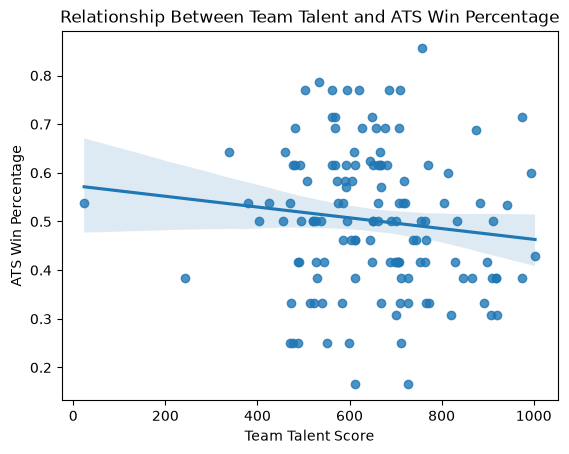

In [26]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x="talent", y="atsWinPct")
plt.title("Relationship Between Team Talent and ATS Win Percentage")
plt.xlabel("Team Talent Score")
plt.ylabel("ATS Win Percentage")
plt.show()


The fitted line slopes slightly downward, but the observations are widely dispersed. This suggests that teams with greater talent were not consistently better at covering the spread. The visual pattern appears weak rather than strongly predictive.


### Team Talent vs. Average Cover Margin

Average cover margin measures how far above or below the betting spread a team finished on average.


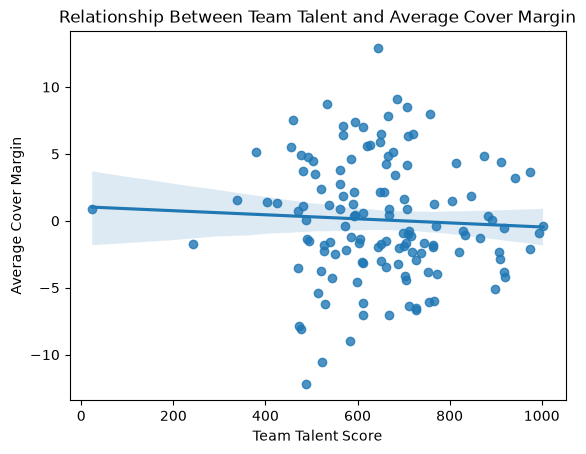

In [27]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x="talent", y="avgCoverMargin")
plt.title("Relationship Between Team Talent and Average Cover Margin")
plt.xlabel("Team Talent Score")
plt.ylabel("Average Cover Margin")
plt.show()


This relationship is also nearly flat. Teams at similar talent levels show both positive and negative average cover margins, indicating that roster talent by itself does not explain much of the variation in market adjusted performance.


### Correlation Analysis

Correlation provides a numerical summary of the linear relationships seen in the scatterplots.


In [28]:
df[["talent", "atsWinPct", "avgCoverMargin"]].corr()


,talent,atsWinPct,avgCoverMargin
talent,1.000000,-0.118951,-0.052675
atsWinPct,-0.118951,1.000000,0.776962
avgCoverMargin,-0.052675,0.776962,1.000000


The correlation between talent and ATS win percentage is -0.12, while the correlation between talent and average cover margin is approximately -0.05. Both are very close to zero, indicating little linear relationship between talent and ATS performance in this sample. ATS win percentage and average cover margin are much more strongly related (approximately 0.78), which is expected because teams that cover more frequently should generally have stronger average cover margins.


### Highest-Ranked Teams by Each Metric

The following charts provide descriptive context by showing the top 10 teams in talent, ATS win percentage, and average cover margin.


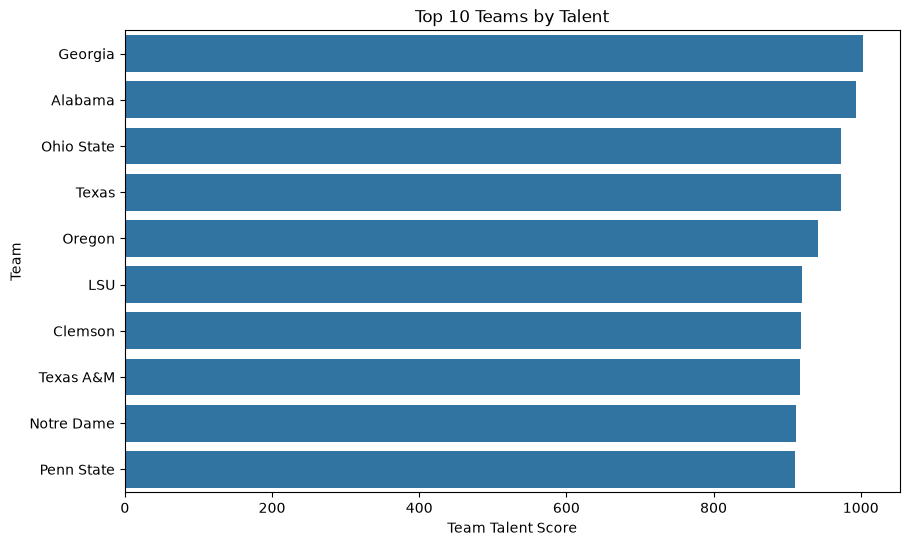

In [29]:
top_talent = df.nlargest(10, "talent")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_talent, x="talent", y="team")
plt.title("Top 10 Teams by Talent")
plt.xlabel("Team Talent Score")
plt.ylabel("Team")
plt.show()


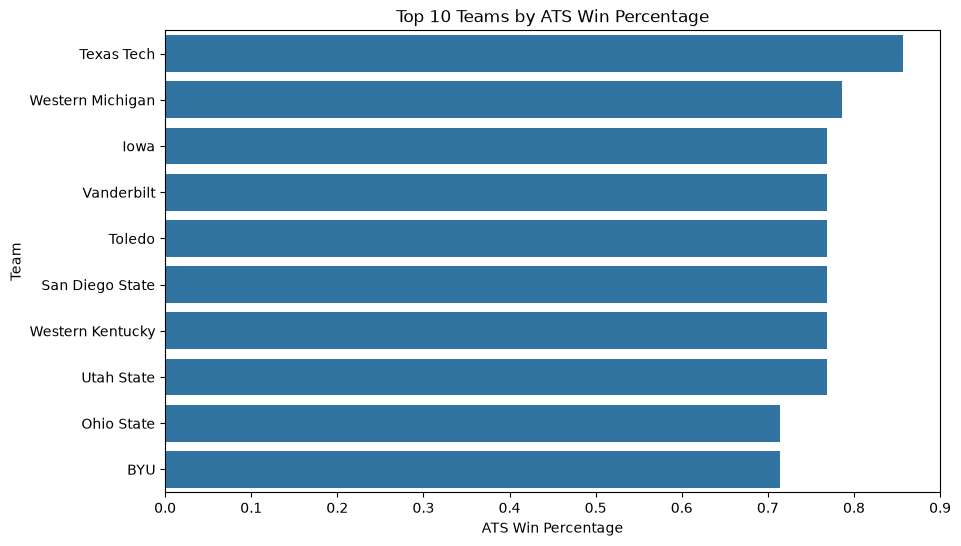

In [30]:
top_ats = df.nlargest(10, "atsWinPct")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ats, x="atsWinPct", y="team")
plt.title("Top 10 Teams by ATS Win Percentage")
plt.xlabel("ATS Win Percentage")
plt.ylabel("Team")
plt.show()


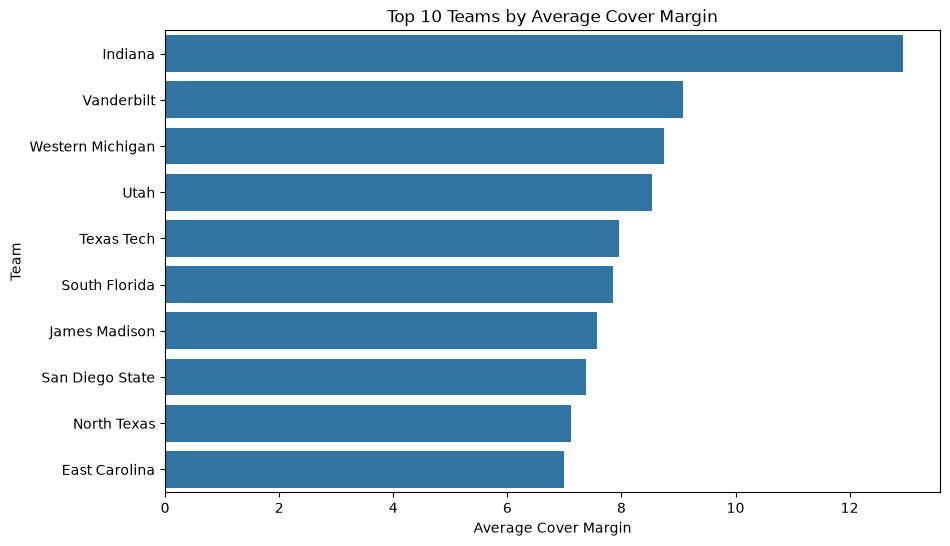

In [32]:
top_cover = df.nlargest(10, "avgCoverMargin")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cover, x="avgCoverMargin", y="team")
plt.title("Top 10 Teams by Average Cover Margin")
plt.xlabel("Average Cover Margin")
plt.ylabel("Team")
plt.show()


## 7. Storytelling and Main Findings

The 2025 data provide little evidence that a more talented roster automatically leads to better performance against the betting spread. The two measures of ATS performance tell a consistent story: talent had only a very weak negative relationship with ATS win percentage and almost no relationship with average cover margin. This result is plausible because point spreads are designed to incorporate expectations about team strength. A talented team may be expected to win by a large margin, making it difficult to cover even when the team wins the game. Conversely, a less talented team can perform well ATS by exceeding relatively lower market expectations. Therefore, the analysis should not be interpreted as evidence that talent makes teams worse. Instead, it suggests that team talent alone was not a useful predictor of whether a team would outperform the betting market during the 2025 season.


## 8. Limitations, Ethics, and Reflection

### Limitations
- The analysis covers only the 2025 season, so the relationship may differ in other seasons.
- Team talent is represented by a single composite score and does not capture injuries, coaching, transfers during the season, player development, or matchup specific factors.
- ATS results depend on betting market spreads, which incorporate information beyond roster talent.
### Ethics
This project uses publicly accessible sports data for analysis. The results should not be treated as gambling advice or as evidence of a reliable betting strategy.
### Reflection and Next Steps
A useful extension would be to repeat the analysis across several seasons, compare conferences, or add variables such as team record, offensive efficiency, defensive efficiency, or preseason expectations. Analysis using multiple seasons would help determine whether the weak relationship observed in 2025 is persistent or season specific.


## 9. Code and Transparency

The complete Python analysis is contained in this notebook. Data were accessed from the CollegeFootballData API through the cfbd Python wrapper.

### Data / Documentation Source
- CollegeFootballData. cfbd-python: Python wrapper for the CFBD API. GitHub: https://github.com/CFBD/cfbd-python
